# Error Analysis

## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter, defaultdict
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, jaccard_score
)
from sklearn.preprocessing import LabelEncoder, MultiLabelBinarizer

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.dpi': 150,
})
PALETTE = {
    'green':  '#2ecc71', 'red':    '#e74c3c',
    'orange': '#f39c12', 'blue':   '#2980b9',
    'purple': '#8e44ad', 'gray':   '#95a5a6',
    'dark':   '#2c3e50',
}
ALL_TECHNIQUES = [
    'gaslighting', 'guilt tripping', 'emotional appeal',
    'character attack', 'deflection', 'framing the narrative',
    'minimization', 'evasion', 'dismissal',
    'playing the victim', 'persuasion'
]

## 2. Load & Merge Data

In [2]:
df_results = pd.read_csv("/kaggle/input/st1-stg2-p2/manipulation_results.csv")
df_test    = pd.read_csv('/kaggle/input/legaldata/test_split.csv')
test       = pd.merge(df_results, df_test, on='Dialogue', how='left')

def parse_techniques(x):
    if pd.isna(x) or str(x).strip().lower() in ("none", "nan", ""):
        return []
    return [t.strip().lower() for t in str(x).split(",")
            if t.strip() and t.strip().lower() != "none"]

test["Manipulation_Present_bin"] = test["Manipulation_Present"].map({'Yes': 1, 'No': 0})
test["Manipulative_bin"]         = test["Manipulative"].astype(int)
test["Primary_Manipulator"]      = test["Primary_Manipulator"].fillna("None").str.strip()
test["Primary Manipulator"]      = test["Primary Manipulator"].fillna("None").str.strip()
test["true_techniques"]          = test["Manipulation Techniques"].apply(parse_techniques)
test["pred_techniques"]          = test["Techniques_Used"].apply(parse_techniques)
test["dialogue_length"]          = test["Dialogue"].str.split().str.len()
test["num_true_techniques"]      = test["true_techniques"].apply(len)
test["num_pred_techniques"]      = test["pred_techniques"].apply(len)

print(f" Loaded {len(test)} samples")
print(f"   Manipulative=1: {test['Manipulative_bin'].sum()} | "
      f"Manipulative=0: {(test['Manipulative_bin']==0).sum()}")

 Loaded 155 samples
   Manipulative=1: 95 | Manipulative=0: 60


## Task 1 – Manipulation Detection

In [3]:
y_true1 = test["Manipulative_bin"].tolist()
y_pred1 = test["Manipulation_Present_bin"].tolist()

acc1 = accuracy_score(y_true1, y_pred1)
pre1 = precision_score(y_true1, y_pred1, zero_division=0)
rec1 = recall_score(y_true1, y_pred1, zero_division=0)
f11  = f1_score(y_true1, y_pred1, average="binary", zero_division=0)
cm1  = confusion_matrix(y_true1, y_pred1)
tn1, fp1, fn1, tp1 = cm1.ravel()

print(f"{'='*55}")
print("TASK 1: MANIPULATION DETECTION")
print(f"{'='*55}")
print(f"  Accuracy : {acc1:.4f}")
print(f"  Precision: {pre1:.4f}")
print(f"  Recall   : {rec1:.4f}")
print(f"  F1       : {f11:.4f}")
print(f"  TP={tp1}  FP={fp1}  TN={tn1}  FN={fn1}")

TASK 1: MANIPULATION DETECTION
  Accuracy : 0.9806
  Precision: 0.9792
  Recall   : 0.9895
  F1       : 0.9843
  TP=94  FP=2  TN=58  FN=1


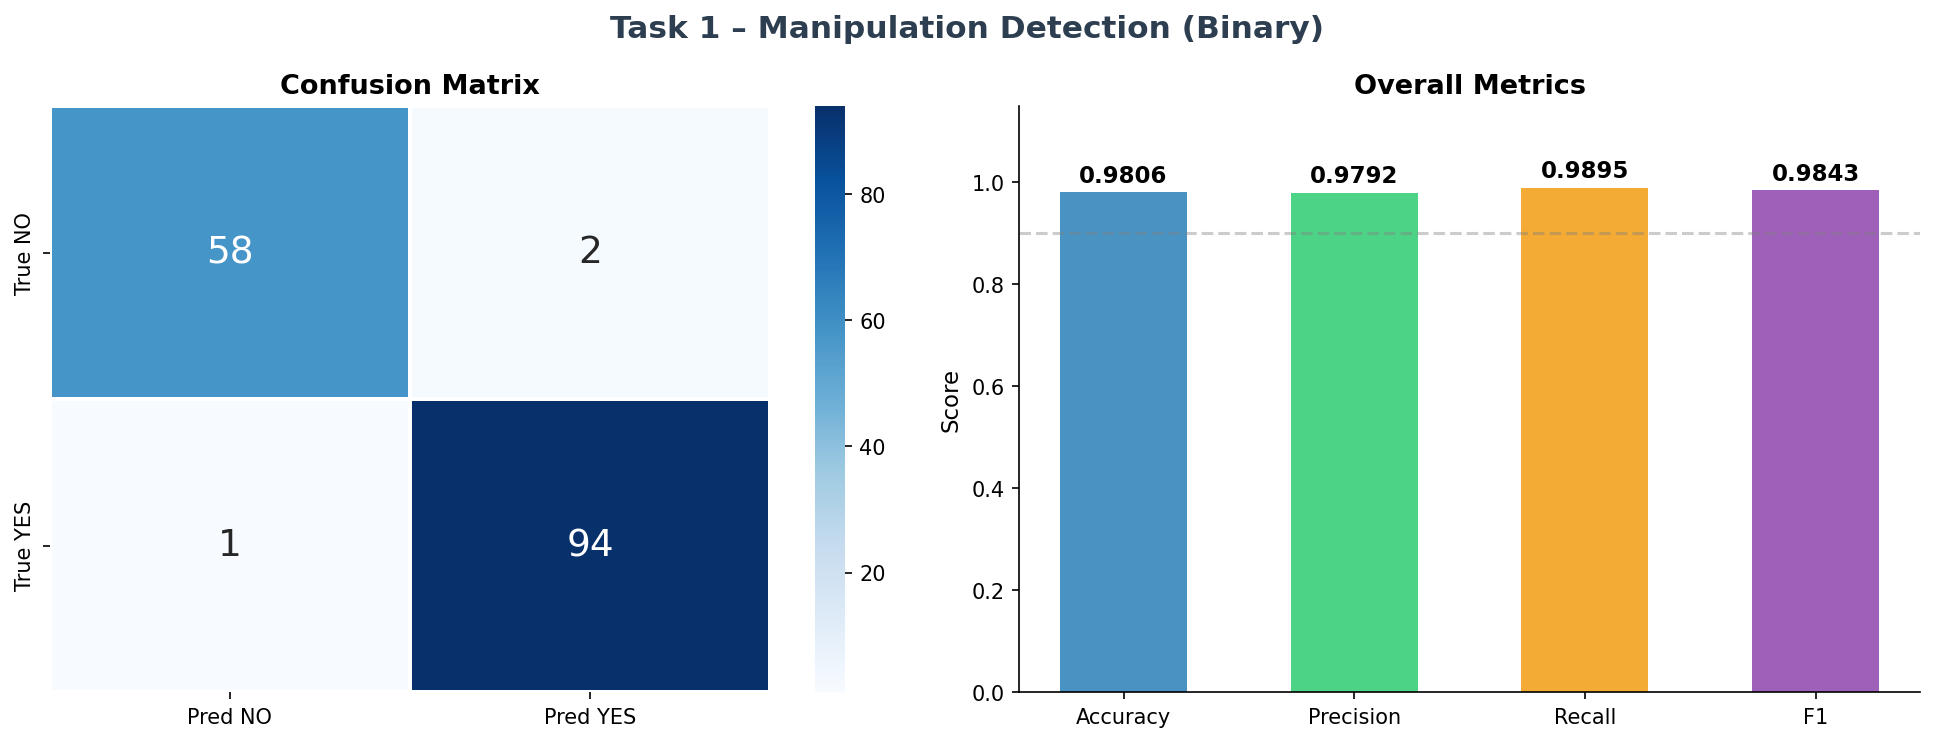

 Saved: task1_A_metrics.png


In [4]:
# Task 1 – Figure A: Confusion Matrix + Metrics Bar
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Task 1 – Manipulation Detection (Binary)",
             fontsize=15, fontweight='bold', color=PALETTE['dark'])

ax = axes[0]
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred NO', 'Pred YES'],
            yticklabels=['True NO', 'True YES'],
            linewidths=1, linecolor='white', ax=ax, annot_kws={"size": 18})
ax.set_title("Confusion Matrix")

ax = axes[1]
metrics_t1 = {'Accuracy': acc1, 'Precision': pre1, 'Recall': rec1, 'F1': f11}
bars = ax.bar(metrics_t1.keys(), metrics_t1.values(),
              color=[PALETTE['blue'], PALETTE['green'],
                     PALETTE['orange'], PALETTE['purple']],
              width=0.55, alpha=0.85)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Score")
ax.set_title("Overall Metrics")
for bar, val in zip(bars, metrics_t1.values()):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02,
            f"{val:.4f}", ha='center', fontweight='bold', fontsize=11)
ax.axhline(0.9, color='gray', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig("task1_A_metrics.png", bbox_inches='tight')
plt.show()
print(" Saved: task1_A_metrics.png")

/tmp/ipykernel_40/2089434831.py:39: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(length_labels, rotation=30, ha='right')


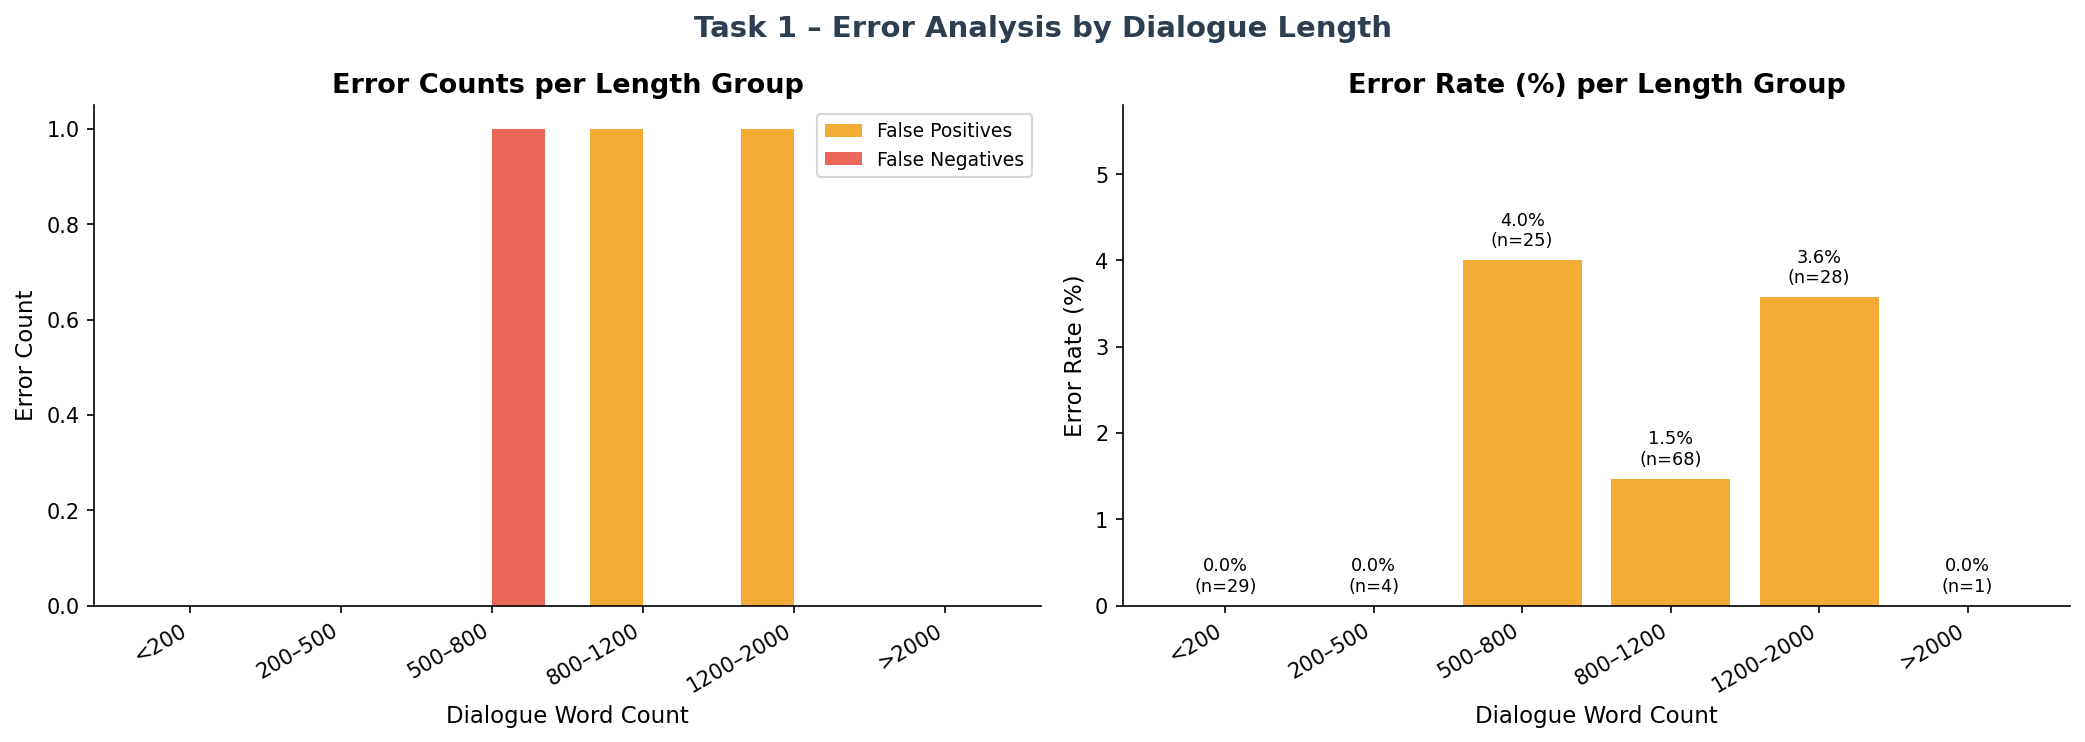

 Saved: task1_B_error_by_length.png


In [5]:
# Task 1 – Figure B: Error by Dialogue Length
length_bins   = [0, 200, 500, 800, 1200, 2000, 9999]
length_labels = ['<200', '200–500', '500–800', '800–1200', '1200–2000', '>2000']
test['len_bin'] = pd.cut(test['dialogue_length'], bins=length_bins,
                          labels=length_labels, ordered=True)

fp_by_len    = test[(test["Manipulative_bin"]==0) & (test["Manipulation_Present_bin"]==1)
                    ]['len_bin'].value_counts().reindex(length_labels, fill_value=0)
fn_by_len    = test[(test["Manipulative_bin"]==1) & (test["Manipulation_Present_bin"]==0)
                    ]['len_bin'].value_counts().reindex(length_labels, fill_value=0)
total_by_len = test['len_bin'].value_counts().reindex(length_labels, fill_value=0)
error_rate   = (fp_by_len + fn_by_len) / total_by_len.replace(0, np.nan) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Task 1 – Error Analysis by Dialogue Length",
             fontsize=14, fontweight='bold', color=PALETTE['dark'])

ax = axes[0]
x, w = np.arange(len(length_labels)), 0.35
ax.bar(x-w/2, fp_by_len.values, w, label='False Positives',
       color=PALETTE['orange'], alpha=0.85)
ax.bar(x+w/2, fn_by_len.values, w, label='False Negatives',
       color=PALETTE['red'], alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(length_labels, rotation=30, ha='right')
ax.set_xlabel("Dialogue Word Count")
ax.set_ylabel("Error Count")
ax.set_title("Error Counts per Length Group")
ax.legend(fontsize=9)

ax = axes[1]
max_rate = error_rate.fillna(0).max()
bar_c = [PALETTE['red'] if r > 10 else PALETTE['orange'] if r > 0
         else PALETTE['green'] for r in error_rate.fillna(0)]
bars = ax.bar(length_labels, error_rate.fillna(0), color=bar_c, alpha=0.85)
ax.set_xlabel("Dialogue Word Count")
ax.set_ylabel("Error Rate (%)")
ax.set_title("Error Rate (%) per Length Group")
ax.set_xticklabels(length_labels, rotation=30, ha='right')
ax.set_ylim(0, max_rate * 1.45)
for bar, (rate, total) in zip(bars, zip(error_rate.fillna(0), total_by_len)):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + max_rate * 0.03,
            f"{rate:.1f}%\n(n={total})", ha='center', va='bottom', fontsize=8.5)

plt.tight_layout()
plt.savefig("task1_B_error_by_length.png", bbox_inches='tight')
plt.show()
print(" Saved: task1_B_error_by_length.png")

In [6]:
# Task 1 – Error Analysis (Text)
print("ERROR ANALYSIS – TASK 1")
print("="*55)

fp_cases = test[(test["Manipulative_bin"]==0) & (test["Manipulation_Present_bin"]==1)]
fn_cases = test[(test["Manipulative_bin"]==1) & (test["Manipulation_Present_bin"]==0)]

print(f"\n### FALSE POSITIVES ({len(fp_cases)} cases — said YES, actually NO):")
for idx, row in fp_cases.iterrows():
    print(f"\n--- Case {idx} ---")
    print(f"Predicted Manipulator : {row['Primary_Manipulator']}")
    print(f"Predicted Techniques  : {row['Techniques_Used']}")
    print(f"Dialogue snippet      : {row['Dialogue'][:300]}...")

print(f"\n### FALSE NEGATIVES ({len(fn_cases)} cases — said NO, actually YES):")
for idx, row in fn_cases.iterrows():
    print(f"\n--- Case {idx} ---")
    print(f"True Manipulator  : {row['Primary Manipulator']}")
    print(f"True Techniques   : {row['Manipulation Techniques']}")
    print(f"Dialogue snippet  : {row['Dialogue'][:300]}...")

print("\n### ERROR BY DIALOGUE LENGTH:")
print(f"  {'Length':>10}  {'Total':>5}  {'FP':>4}  {'FN':>4}  {'Error Rate':>10}")
print("  " + "-"*42)
for lbl in length_labels:
    print(f"  {lbl:>10}  {total_by_len[lbl]:>5}  "
          f"{fp_by_len[lbl]:>4}  {fn_by_len[lbl]:>4}  "
          f"{error_rate[lbl]:>9.1f}%")

ERROR ANALYSIS – TASK 1

### FALSE POSITIVES (2 cases — said YES, actually NO):

--- Case 90 ---
Predicted Manipulator : Defendant
Predicted Techniques  : emotional appeal
Dialogue snippet      : Judge: Four days. Okay. So would four days be an unreasonable length of time for a detention for the two misdemeanors?
Defendant: 's Lawyer: It's not that it would be an unreasonable length of time. It's that precedent says that the length of detention must be authorized by a neutral and detached ma...

--- Case 107 ---
Predicted Manipulator : Defendant
Predicted Techniques  : emotional appeal
Dialogue snippet      : Judge: Mr. Chief Justice, and may it please the Court: In Robinson, this Court held that the government cannot criminalize status. And Respondent has conceded here today that the City cannot criminalize the status of being homeless. Our narrow submission in this case is that government cannot circum...

### FALSE NEGATIVES (1 cases — said NO, actually YES):

--- Case 137 ---
True 

## Task 2 – Primary Manipulator Identification

In [7]:
le = LabelEncoder()
all_cats = list(set(test["Primary Manipulator"].tolist() +
                    test["Primary_Manipulator"].tolist()))
le.fit(all_cats)
y_true2    = le.transform(test["Primary Manipulator"])
y_pred2    = le.transform(test["Primary_Manipulator"])
class_names = le.classes_

acc2 = accuracy_score(y_true2, y_pred2)
pre2 = precision_score(y_true2, y_pred2, average='weighted', zero_division=0)
rec2 = recall_score(y_true2, y_pred2, average='weighted', zero_division=0)
f12  = f1_score(y_true2, y_pred2, average='weighted', zero_division=0)
cm2  = confusion_matrix(y_true2, y_pred2)

per_stats = {}
for i, cls in enumerate(class_names):
    tp = cm2[i, i]
    fp = cm2[:, i].sum() - tp
    fn = cm2[i, :].sum() - tp
    p  = tp/(tp+fp) if (tp+fp) > 0 else 0
    r  = tp/(tp+fn) if (tp+fn) > 0 else 0
    f  = 2*p*r/(p+r) if (p+r) > 0 else 0
    per_stats[cls] = {'precision': p, 'recall': r, 'f1': f,
                      'support': int(cm2[i, :].sum())}

print(f"{'='*55}")
print("TASK 2: PRIMARY MANIPULATOR IDENTIFICATION")
print(f"{'='*55}")
print(f"  Accuracy : {acc2:.4f}")
print(f"  Precision: {pre2:.4f} (weighted)")
print(f"  Recall   : {rec2:.4f} (weighted)")
print(f"  F1       : {f12:.4f} (weighted)")
print(f"\n  Per-Class Metrics:")
print(f"  {'Class':<12}  {'Support':>7}  {'P':>6}  {'R':>6}  {'F1':>6}")
print("  " + "-"*42)
for cls in class_names:
    s = per_stats[cls]
    print(f"  {cls:<12}  {s['support']:>7}  "
          f"{s['precision']:>6.3f}  {s['recall']:>6.3f}  {s['f1']:>6.3f}")

TASK 2: PRIMARY MANIPULATOR IDENTIFICATION
  Accuracy : 0.8387
  Precision: 0.8499 (weighted)
  Recall   : 0.8387 (weighted)
  F1       : 0.8421 (weighted)

  Per-Class Metrics:
  Class         Support       P       R      F1
  ------------------------------------------
  Defendant          63   0.842   0.762   0.800
  None               60   0.983   0.967   0.975
  Plaintiff          32   0.615   0.750   0.676


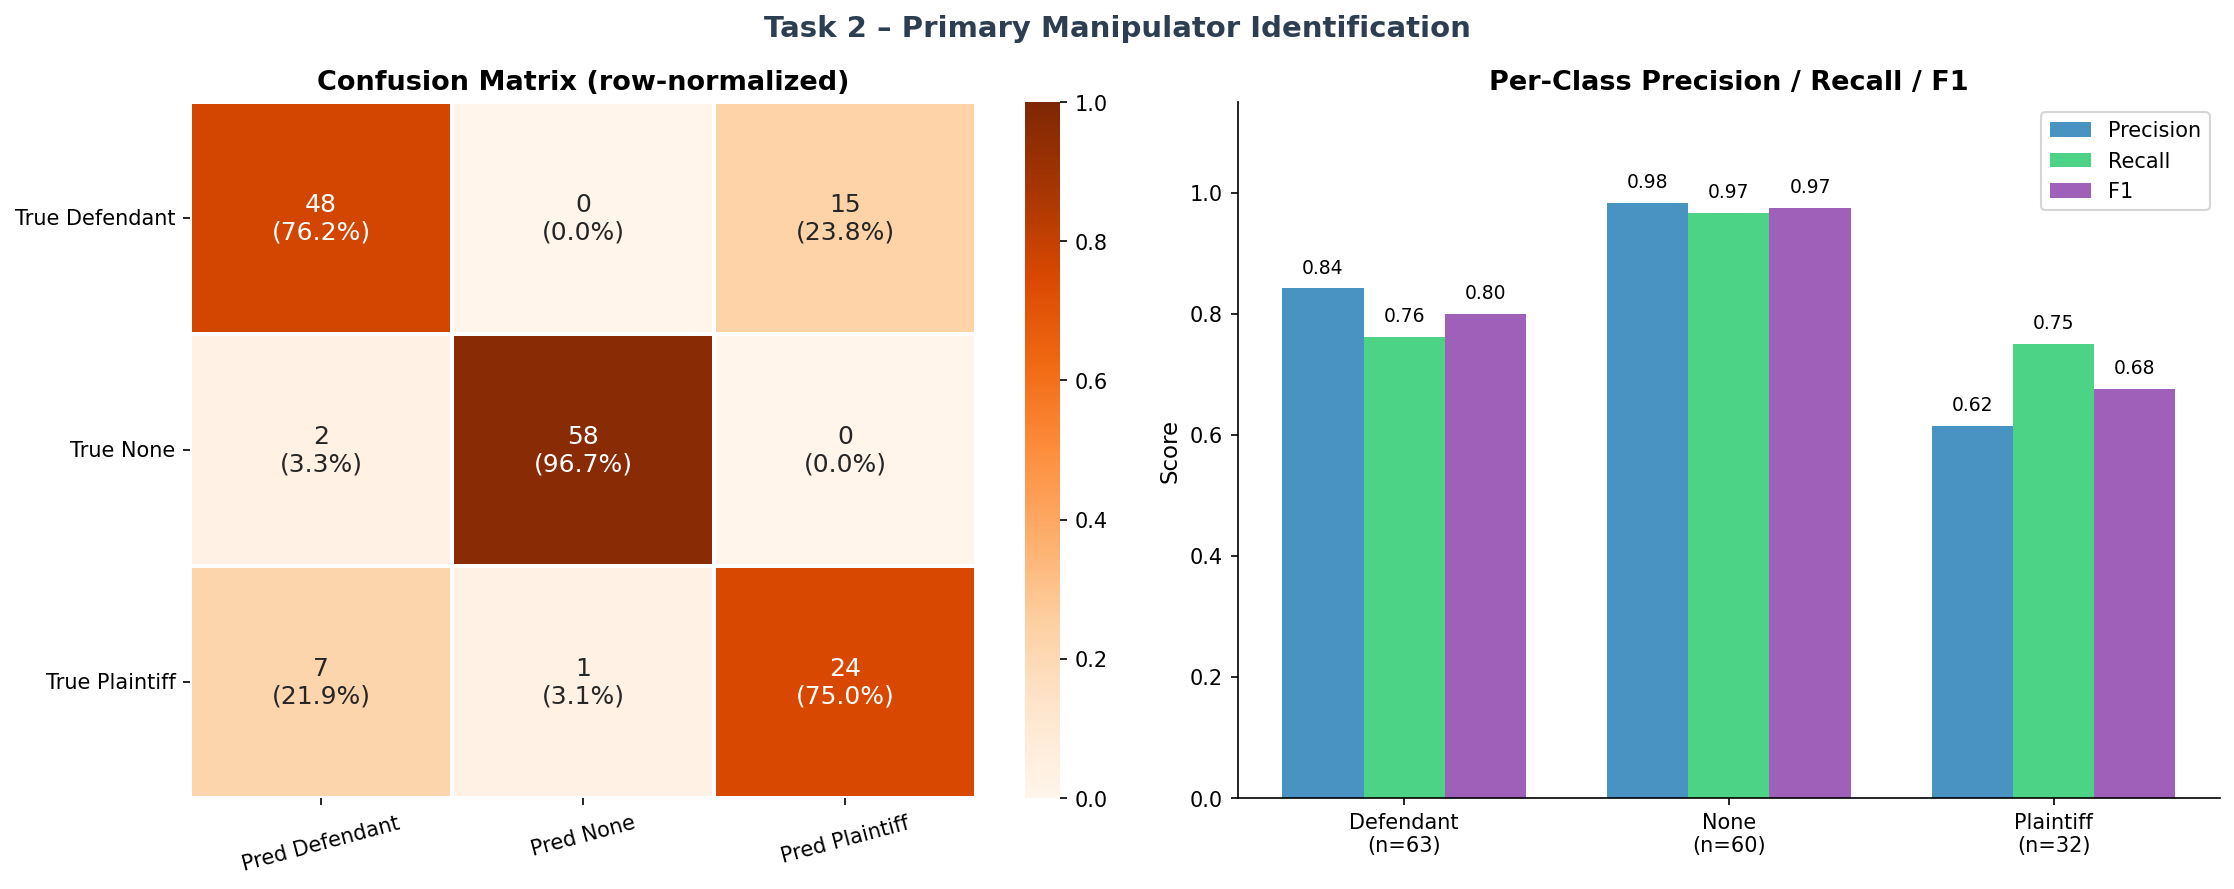

✅ Saved: task2_metrics.png


In [8]:
# Task 2 – Figure: Confusion Matrix + Per-Class P/R/F1
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Task 2 – Primary Manipulator Identification",
             fontsize=14, fontweight='bold', color=PALETTE['dark'])

ax = axes[0]
cm2_norm = cm2.astype(float) / cm2.sum(axis=1, keepdims=True)
annots = np.array([[f"{cm2[i][j]}\n({cm2_norm[i][j]*100:.1f}%)"
                    for j in range(len(class_names))]
                   for i in range(len(class_names))])
sns.heatmap(cm2_norm, annot=annots, fmt='', cmap='Oranges',
            xticklabels=[f"Pred {c}" for c in class_names],
            yticklabels=[f"True {c}" for c in class_names],
            linewidths=1, linecolor='white', ax=ax, vmin=0, vmax=1,
            annot_kws={"size": 12})
ax.set_title("Confusion Matrix (row-normalized)")
ax.tick_params(axis='x', rotation=15)
ax.tick_params(axis='y', rotation=0)

ax = axes[1]
x = np.arange(len(class_names))
w = 0.25
ax.bar(x-w, [per_stats[c]['precision'] for c in class_names], w,
       label='Precision', color=PALETTE['blue'], alpha=0.85)
ax.bar(x,   [per_stats[c]['recall']    for c in class_names], w,
       label='Recall',    color=PALETTE['green'], alpha=0.85)
ax.bar(x+w, [per_stats[c]['f1']        for c in class_names], w,
       label='F1',        color=PALETTE['purple'], alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([f"{c}\n(n={per_stats[c]['support']})"
                    for c in class_names])
ax.set_ylim(0, 1.15)
ax.set_ylabel("Score")
ax.set_title("Per-Class Precision / Recall / F1")
ax.legend()
for xi, cls in enumerate(class_names):
    ax.text(xi-w, per_stats[cls]['precision']+0.025,
            f"{per_stats[cls]['precision']:.2f}", ha='center', fontsize=9)
    ax.text(xi,   per_stats[cls]['recall']+0.025,
            f"{per_stats[cls]['recall']:.2f}", ha='center', fontsize=9)
    ax.text(xi+w, per_stats[cls]['f1']+0.025,
            f"{per_stats[cls]['f1']:.2f}", ha='center', fontsize=9)

plt.tight_layout()
plt.savefig("task2_metrics.png", bbox_inches='tight')
plt.show()
print("✅ Saved: task2_metrics.png")

In [9]:
# Task 2 – Error Analysis (Text)
print("ERROR ANALYSIS – TASK 2")
print("="*55)

error_cases = test[test["Primary Manipulator"] != test["Primary_Manipulator"]]

print(f"\n### CONFUSION BREAKDOWN:")
for true_cls in ['Plaintiff', 'Defendant', 'None']:
    subset = test[test["Primary Manipulator"] == true_cls]
    errors = subset[subset["Primary_Manipulator"] != true_cls]
    if len(errors) > 0:
        print(f"\n{true_cls} ({len(subset)} total, {len(errors)} errors):")
        for pred_cls, count in errors["Primary_Manipulator"].value_counts().items():
            print(f"  → predicted as {pred_cls}: {count}/{len(subset)} "
                  f"({count/len(subset)*100:.1f}%)")

print(f"\n### SAMPLE ERROR CASES (first 5):")
for idx, row in error_cases.head(5).iterrows():
    print(f"\n--- Case {idx} ---")
    print(f"True Manipulator : {row['Primary Manipulator']}")
    print(f"Pred Manipulator : {row['Primary_Manipulator']}")
    print(f"True Techniques  : {row['Manipulation Techniques']}")
    print(f"Pred Techniques  : {row['Techniques_Used']}")
    print(f"Dialogue snippet : {row['Dialogue'][:250]}...")

ERROR ANALYSIS – TASK 2

### CONFUSION BREAKDOWN:

Plaintiff (32 total, 8 errors):
  → predicted as Defendant: 7/32 (21.9%)
  → predicted as None: 1/32 (3.1%)

Defendant (63 total, 15 errors):
  → predicted as Plaintiff: 15/63 (23.8%)

None (60 total, 2 errors):
  → predicted as Defendant: 2/60 (3.3%)

### SAMPLE ERROR CASES (first 5):

--- Case 7 ---
True Manipulator : Defendant
Pred Manipulator : Plaintiff
True Techniques  : gaslighting, character attack, playing the victim
Pred Techniques  : persuasion, playing the victim, gaslighting, deflection, minimization, guilt tripping, emotional appeal
Dialogue snippet : Judge: This is the plaintiff, Lorna Lewis. She says the defendant, her upstairs neighbor, has been harassing her mercilessly. He calls her every dirty name under the sun, bangs on her door at all hours of the day and night, and makes obscene gestures...

--- Case 17 ---
True Manipulator : Defendant
Pred Manipulator : Plaintiff
True Techniques  : deflection, minimization
Pred

## Task 3 – Technique Classification

In [10]:
tech_metrics = []
for tech in ALL_TECHNIQUES:
    yt = test["true_techniques"].apply(lambda x: tech in x)
    yp = test["pred_techniques"].apply(lambda x: tech in x)
    tp = int((yt & yp).sum())
    fp = int((~yt & yp).sum())
    fn = int((yt & ~yp).sum())
    support = int(yt.sum())
    p = tp/(tp+fp) if (tp+fp) > 0 else 0.0
    r = tp/(tp+fn) if (tp+fn) > 0 else 0.0
    f = 2*p*r/(p+r) if (p+r) > 0 else 0.0
    tech_metrics.append({'technique': tech, 'tp': tp, 'fp': fp, 'fn': fn,
                         'support': support, 'precision': p,
                         'recall': r, 'f1': f})

tech_df = pd.DataFrame(tech_metrics).sort_values('f1', ascending=False)

mlb = MultiLabelBinarizer(classes=ALL_TECHNIQUES)
mlb.fit([ALL_TECHNIQUES])
y_true3     = mlb.transform(test["true_techniques"])
y_pred3     = mlb.transform(test["pred_techniques"])
mask_pos    = (y_true3.sum(axis=1) > 0)
jaccard_all = jaccard_score(y_true3, y_pred3, average='samples', zero_division=1)
jaccard_pos = jaccard_score(y_true3[mask_pos], y_pred3[mask_pos],
                             average='samples', zero_division=0)
f1_macro3   = f1_score(y_true3, y_pred3, average='macro', zero_division=0)
acc3        = accuracy_score(y_true3, y_pred3)

print(f"{'='*55}")
print("TASK 3: TECHNIQUE CLASSIFICATION (Multi-label)")
print(f"{'='*55}")
print(f"  Exact-Match Accuracy    : {acc3:.4f}")
print(f"  F1 (macro)              : {f1_macro3:.4f}")
print(f"  Jaccard (all incl None) : {jaccard_all:.4f}")
print(f"  Jaccard (positive only) : {jaccard_pos:.4f}")
print(f"\n  {'Technique':<25} {'Sup':>4}  {'P':>6}  {'R':>6}  {'F1':>6}  {'FP':>4}  {'FN':>4}")
print("  " + "-"*58)
for _, row in tech_df.iterrows():
    print(f"  {row['technique']:<25} {row['support']:>4}  "
          f"{row['precision']:>6.3f}  {row['recall']:>6.3f}  "
          f"{row['f1']:>6.3f}  {row['fp']:>4}  {row['fn']:>4}")

TASK 3: TECHNIQUE CLASSIFICATION (Multi-label)
  Exact-Match Accuracy    : 0.3742
  F1 (macro)              : 0.3520
  Jaccard (all incl None) : 0.5485
  Jaccard (positive only) : 0.2844

  Technique                  Sup       P       R      F1    FP    FN
  ----------------------------------------------------------
  deflection                  57   0.613   1.000   0.760    36     0
  gaslighting                 30   0.337   0.933   0.496    55     2
  playing the victim          30   0.333   0.800   0.471    48     6
  minimization                29   0.333   0.655   0.442    38    10
  persuasion                  16   0.259   0.938   0.405    43     1
  evasion                     24   0.286   0.667   0.400    40     8
  emotional appeal            23   0.234   0.957   0.376    72     1
  guilt tripping               6   0.167   0.167   0.167     5     5
  framing the narrative        8   0.095   0.250   0.138    19     6
  character attack             4   0.071   0.250   0.111    1

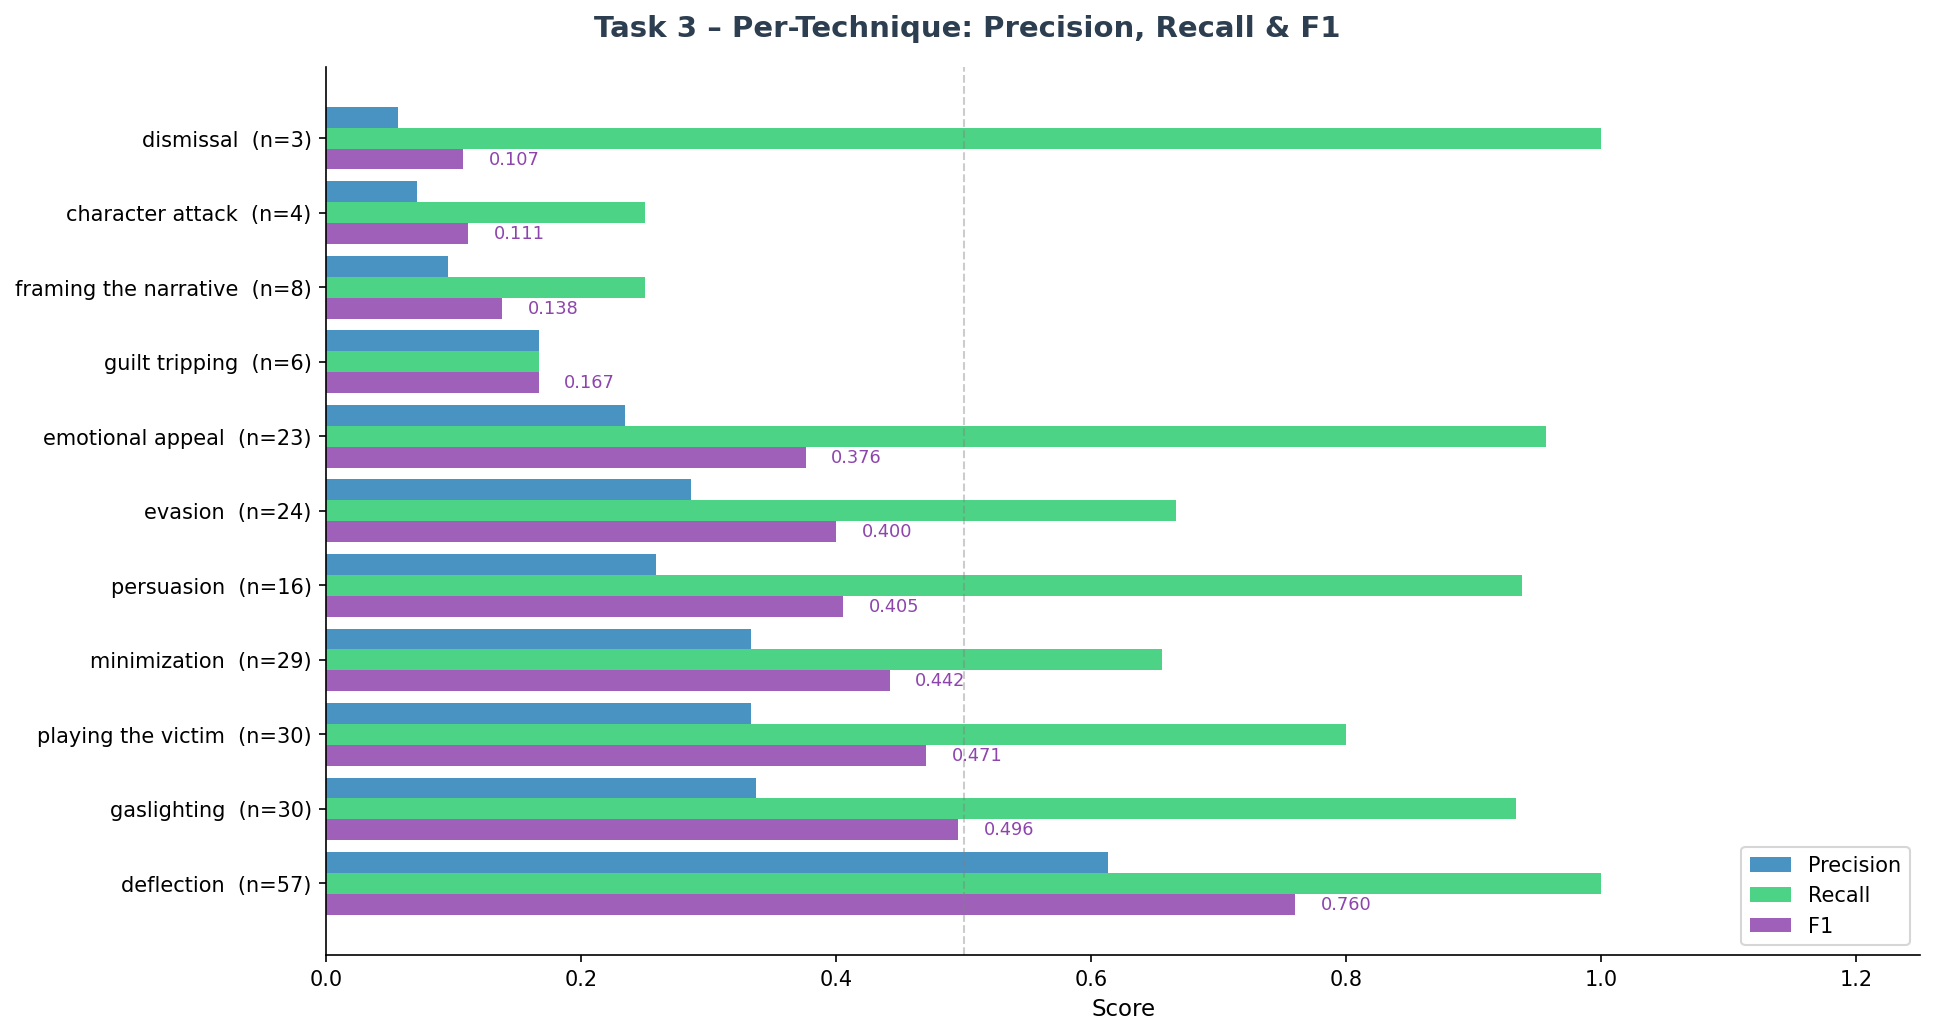

✅ Saved: task3_A_per_technique.png


In [11]:
# Task 3 – Figure A: Per-Technique P/R/F1
fig, ax = plt.subplots(figsize=(13, 7))
fig.suptitle("Task 3 – Per-Technique: Precision, Recall & F1",
             fontsize=14, fontweight='bold', color=PALETTE['dark'])

y_pos_t = np.arange(len(tech_df))
w = 0.28
ax.barh(y_pos_t+w, tech_df['precision'], w, label='Precision',
        color=PALETTE['blue'],   alpha=0.85)
ax.barh(y_pos_t,   tech_df['recall'],    w, label='Recall',
        color=PALETTE['green'],  alpha=0.85)
ax.barh(y_pos_t-w, tech_df['f1'],        w, label='F1',
        color=PALETTE['purple'], alpha=0.85)
ax.set_yticks(y_pos_t)
ax.set_yticklabels([f"{r['technique']}  (n={r['support']})"
                    for _, r in tech_df.iterrows()])
ax.set_xlim(0, 1.25)
ax.set_xlabel("Score")
ax.axvline(0.5, color='gray', linestyle='--', alpha=0.4, linewidth=1)
ax.legend(loc='lower right')
for i, (_, row) in enumerate(tech_df.iterrows()):
    ax.text(row['f1']+0.02, i-w, f"{row['f1']:.3f}",
            va='center', fontsize=8.5, color=PALETTE['purple'])

plt.tight_layout()
plt.savefig("task3_A_per_technique.png", bbox_inches='tight')
plt.show()
print("✅ Saved: task3_A_per_technique.png")

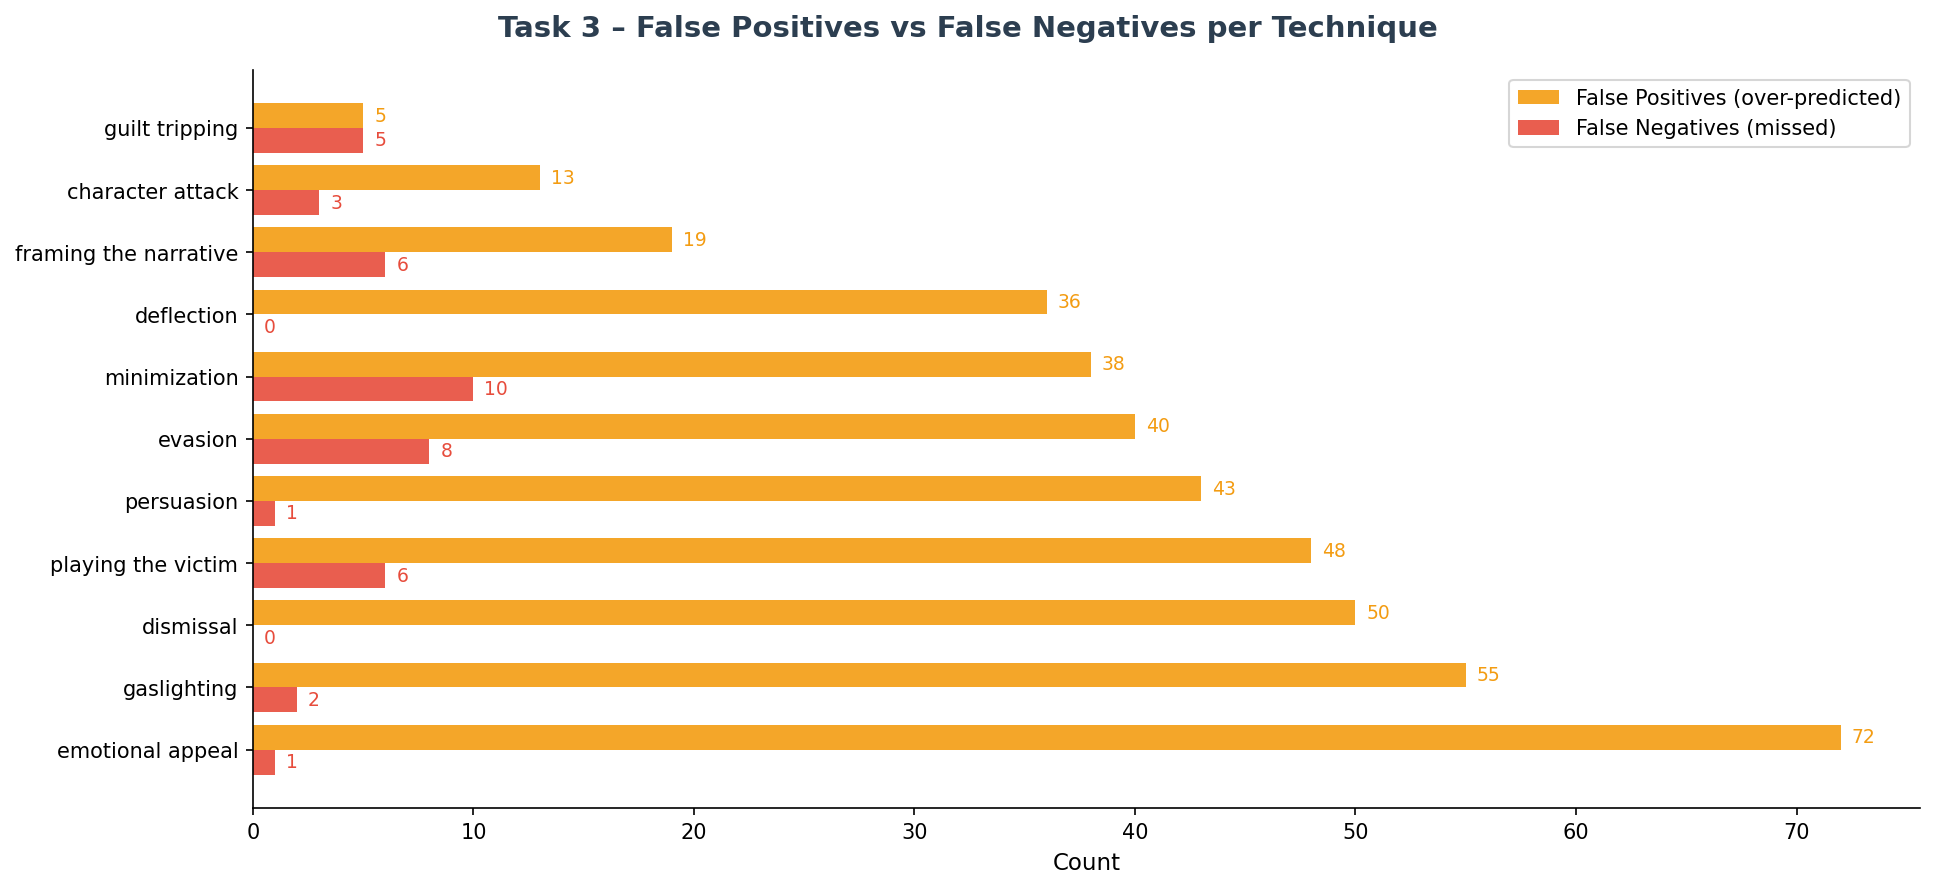

✅ Saved: task3_B_fp_fn.png


In [12]:
# Task 3 – Figure B: FP vs FN per Technique
fig, ax = plt.subplots(figsize=(13, 6))
fig.suptitle("Task 3 – False Positives vs False Negatives per Technique",
             fontsize=14, fontweight='bold', color=PALETTE['dark'])

tech_df_err = tech_df.sort_values('fp', ascending=False)
y = np.arange(len(tech_df_err))
ax.barh(y+0.2, tech_df_err['fp'], 0.4,
        label='False Positives (over-predicted)', color=PALETTE['orange'], alpha=0.9)
ax.barh(y-0.2, tech_df_err['fn'], 0.4,
        label='False Negatives (missed)',         color=PALETTE['red'],    alpha=0.9)
ax.set_yticks(y)
ax.set_yticklabels(tech_df_err['technique'])
ax.set_xlabel("Count")
ax.legend()
for i, (_, row) in enumerate(tech_df_err.iterrows()):
    ax.text(row['fp']+0.5, i+0.2, str(row['fp']), va='center',
            fontsize=9, color=PALETTE['orange'])
    ax.text(row['fn']+0.5, i-0.2, str(row['fn']), va='center',
            fontsize=9, color=PALETTE['red'])

plt.tight_layout()
plt.savefig("task3_B_fp_fn.png", bbox_inches='tight')
plt.show()
print("✅ Saved: task3_B_fp_fn.png")

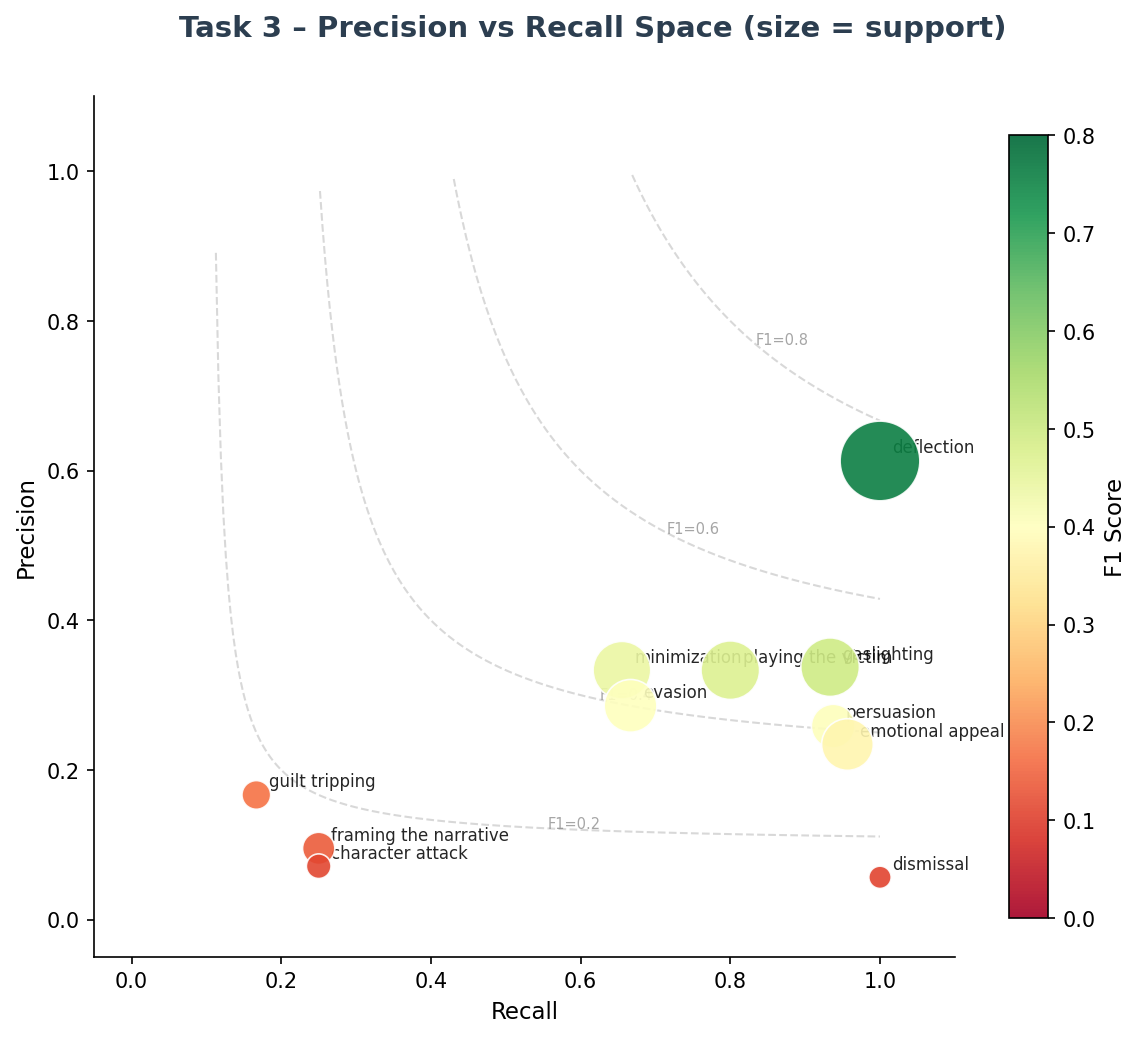

✅ Saved: task3_C_pr_scatter.png


In [13]:
# Task 3 – Figure C: Precision vs Recall Scatter
fig, ax = plt.subplots(figsize=(8, 7))
fig.suptitle("Task 3 – Precision vs Recall Space (size = support)",
             fontsize=14, fontweight='bold', color=PALETTE['dark'])

for f1_level in [0.2, 0.4, 0.6, 0.8]:
    x_vals = np.linspace(0.01, 1.0, 300)
    y_vals = f1_level * x_vals / (2 * x_vals - f1_level)
    mask = (y_vals >= 0) & (y_vals <= 1)
    ax.plot(x_vals[mask], y_vals[mask], '--', color='gray', alpha=0.3, linewidth=1)
    idx = np.where(mask)[0]
    if len(idx) > 20:
        mid = idx[len(idx)//2]
        ax.text(x_vals[mid], y_vals[mid], f'F1={f1_level}',
                fontsize=7, color='gray', alpha=0.7)

scatter = ax.scatter(
    tech_df['recall'], tech_df['precision'],
    s=tech_df['support']*25+40,
    c=tech_df['f1'], cmap='RdYlGn', vmin=0, vmax=0.8,
    edgecolors='white', linewidth=0.8, alpha=0.9, zorder=5
)
for _, row in tech_df.iterrows():
    ax.annotate(row['technique'], xy=(row['recall'], row['precision']),
                xytext=(6, 4), textcoords='offset points', fontsize=8, alpha=0.85)

plt.colorbar(scatter, ax=ax, label='F1 Score', shrink=0.85)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_xlim(-0.05, 1.1)
ax.set_ylim(-0.05, 1.1)
ax.set_aspect('equal')

plt.tight_layout()
plt.savefig("task3_C_pr_scatter.png", bbox_inches='tight')
plt.show()
print("✅ Saved: task3_C_pr_scatter.png")

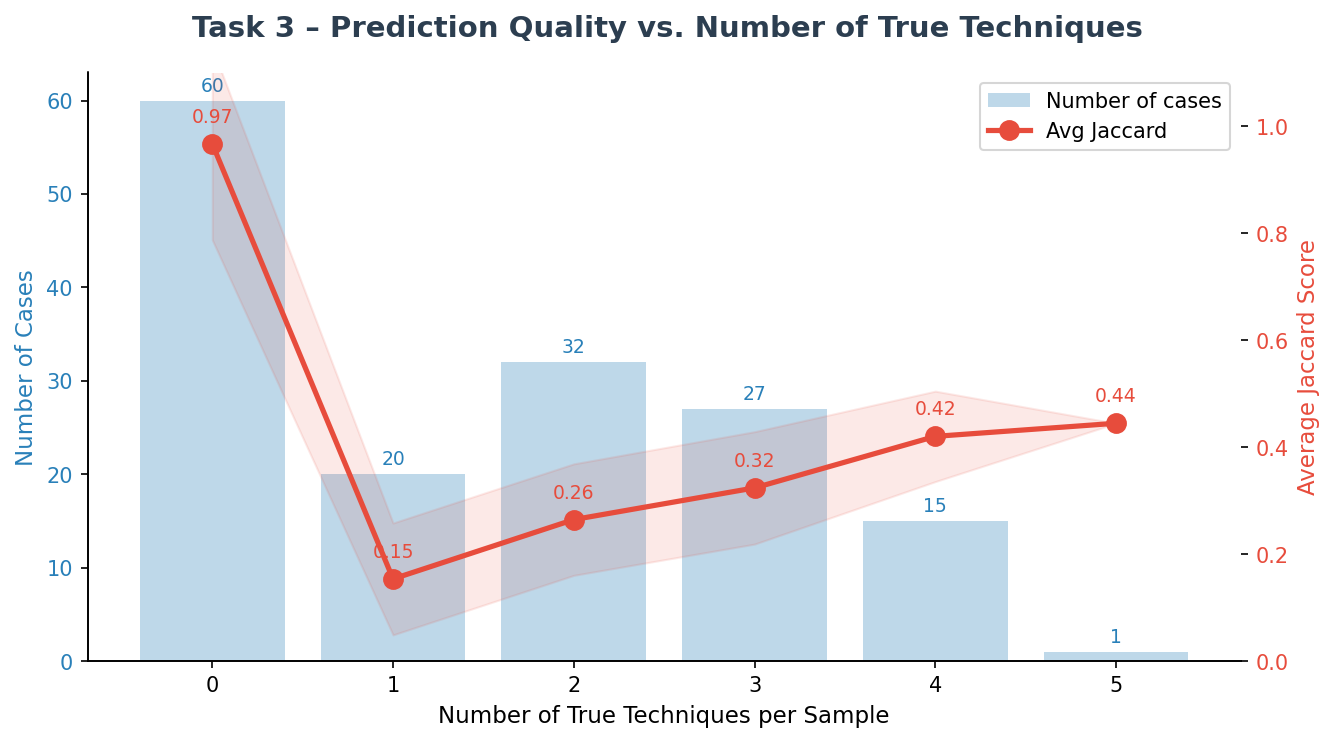

✅ Saved: task3_D_jaccard_complexity.png


In [14]:
# Task 3 – Figure D: Jaccard by Complexity
rows_jac = []
for n in range(0, 6):
    subset = test[test['num_true_techniques'] == n]
    if len(subset) == 0:
        continue
    jacs = [len(set(r['true_techniques']) & set(r['pred_techniques'])) /
            len(set(r['true_techniques']) | set(r['pred_techniques']))
            if len(set(r['true_techniques']) | set(r['pred_techniques'])) > 0 else 1.0
            for _, r in subset.iterrows()]
    rows_jac.append({'n': n, 'count': len(subset),
                     'jaccard': np.mean(jacs), 'jaccard_std': np.std(jacs)})
df_jac = pd.DataFrame(rows_jac)

fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle("Task 3 – Prediction Quality vs. Number of True Techniques",
             fontsize=14, fontweight='bold', color=PALETTE['dark'])
ax2 = ax.twinx()
ax.bar(df_jac['n'], df_jac['count'], color=PALETTE['blue'],
       alpha=0.3, label='Number of cases')
ax2.plot(df_jac['n'], df_jac['jaccard'], 'o-', color=PALETTE['red'],
         linewidth=2.5, markersize=9, label='Avg Jaccard')
ax2.fill_between(df_jac['n'],
                 df_jac['jaccard']-df_jac['jaccard_std'],
                 df_jac['jaccard']+df_jac['jaccard_std'],
                 color=PALETTE['red'], alpha=0.12)
ax.set_xlabel("Number of True Techniques per Sample")
ax.set_ylabel("Number of Cases", color=PALETTE['blue'])
ax2.set_ylabel("Average Jaccard Score", color=PALETTE['red'])
ax.tick_params(axis='y', labelcolor=PALETTE['blue'])
ax2.tick_params(axis='y', labelcolor=PALETTE['red'])
ax2.set_ylim(0, 1.1)
for _, row in df_jac.iterrows():
    ax.text(row['n'], row['count']+1, str(int(row['count'])),
            ha='center', fontsize=9, color=PALETTE['blue'])
    ax2.text(row['n'], row['jaccard']+0.04, f"{row['jaccard']:.2f}",
             ha='center', fontsize=9, color=PALETTE['red'])
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, labels1+labels2, loc='upper right')

plt.tight_layout()
plt.savefig("task3_D_jaccard_complexity.png", bbox_inches='tight')
plt.show()
print("✅ Saved: task3_D_jaccard_complexity.png")

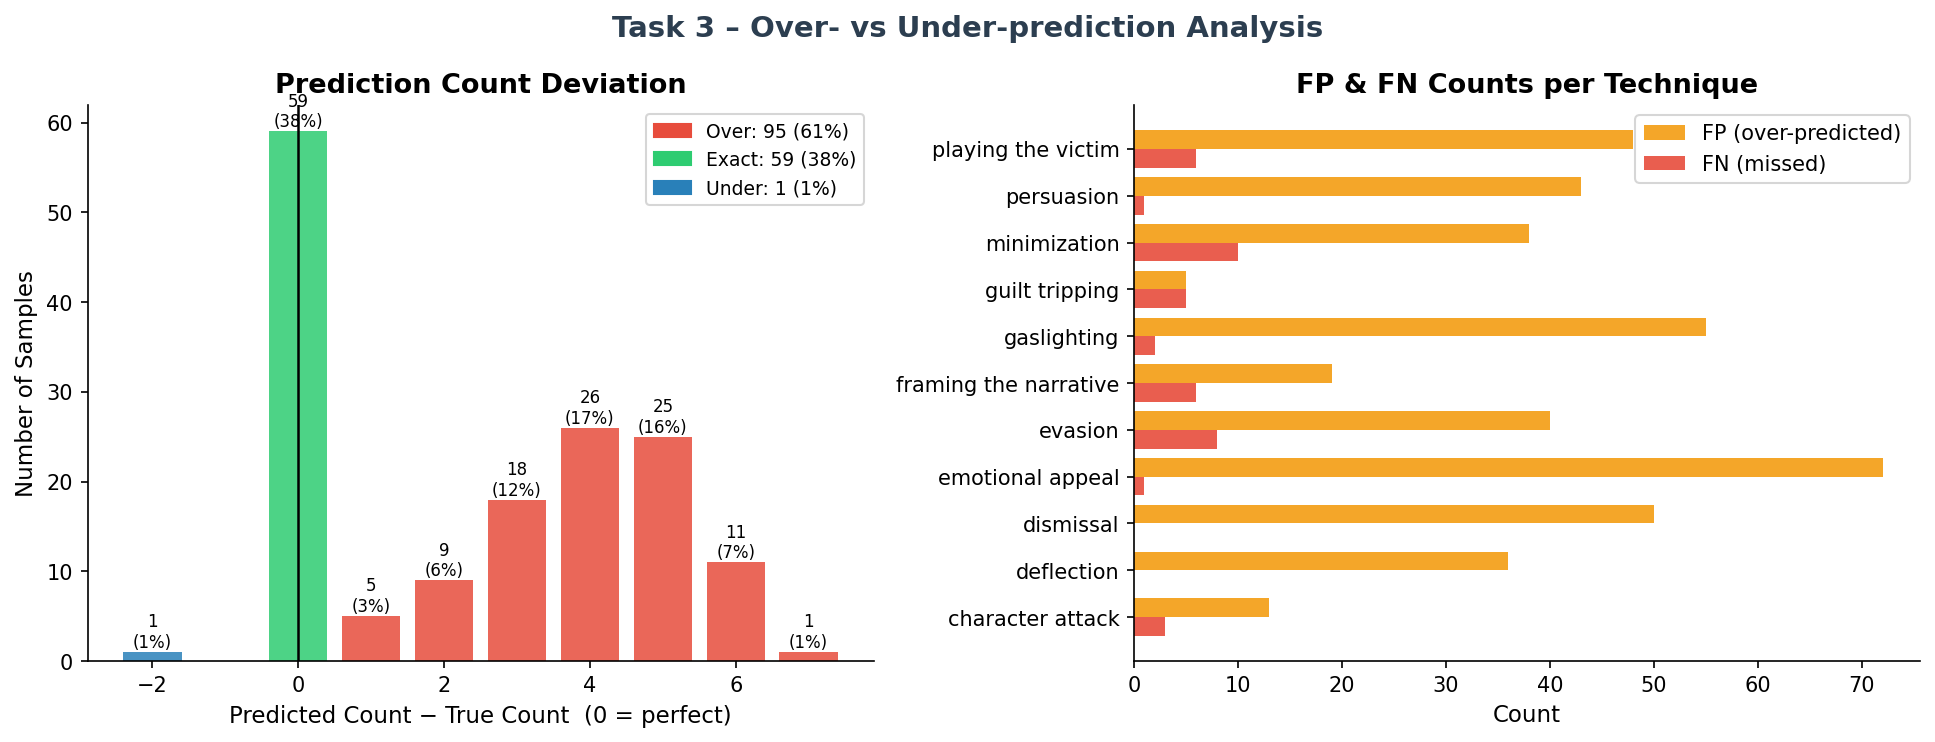

✅ Saved: task3_E_overprediction.png


In [15]:
# Task 3 – Figure E: Over/Under Prediction
diff        = test['num_pred_techniques'] - test['num_true_techniques']
diff_counts = diff.value_counts().sort_index()
over  = (diff > 0).sum()
under = (diff < 0).sum()
exact = (diff == 0).sum()

fp_cnt = Counter([tech for _, row in test.iterrows()
                  for tech in set(row['pred_techniques']) - set(row['true_techniques'])])
fn_cnt = Counter([tech for _, row in test.iterrows()
                  for tech in set(row['true_techniques']) - set(row['pred_techniques'])])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Task 3 – Over- vs Under-prediction Analysis",
             fontsize=14, fontweight='bold', color=PALETTE['dark'])

ax = axes[0]
bar_colors2 = [PALETTE['red'] if d > 0 else PALETTE['green'] if d == 0
               else PALETTE['blue'] for d in diff_counts.index]
ax.bar(diff_counts.index, diff_counts.values, color=bar_colors2, alpha=0.85)
ax.set_xlabel("Predicted Count − True Count  (0 = perfect)")
ax.set_ylabel("Number of Samples")
ax.set_title("Prediction Count Deviation")
total = diff_counts.sum()
for xi, yi in zip(diff_counts.index, diff_counts.values):
    ax.text(xi, yi+0.5, f"{yi}\n({yi/total*100:.0f}%)", ha='center', fontsize=8)
ax.axvline(0, color='black', linewidth=1.2)
ax.legend(handles=[
    mpatches.Patch(color=PALETTE['red'],
                   label=f'Over: {over} ({over/len(test)*100:.0f}%)'),
    mpatches.Patch(color=PALETTE['green'],
                   label=f'Exact: {exact} ({exact/len(test)*100:.0f}%)'),
    mpatches.Patch(color=PALETTE['blue'],
                   label=f'Under: {under} ({under/len(test)*100:.0f}%)'),
], fontsize=9)

ax = axes[1]
all_techs_plot = sorted(set(list(fp_cnt.keys()) + list(fn_cnt.keys())))
fp_vals = [fp_cnt.get(t, 0) for t in all_techs_plot]
fn_vals = [fn_cnt.get(t, 0) for t in all_techs_plot]
y = np.arange(len(all_techs_plot))
ax.barh(y+0.2, fp_vals, 0.4, color=PALETTE['orange'], alpha=0.9,
        label='FP (over-predicted)')
ax.barh(y-0.2, fn_vals, 0.4, color=PALETTE['red'], alpha=0.9,
        label='FN (missed)')
ax.set_yticks(y)
ax.set_yticklabels(all_techs_plot)
ax.set_xlabel("Count")
ax.set_title("FP & FN Counts per Technique")
ax.legend()

plt.tight_layout()
plt.savefig("task3_E_overprediction.png", bbox_inches='tight')
plt.show()
print("✅ Saved: task3_E_overprediction.png")

In [16]:
# Task 3 – Error Analysis (Text)
print("ERROR ANALYSIS – TASK 3")
print("="*55)

print(f"\n### OVER/UNDER PREDICTION:")
print(f"  Over-predict  : {over} ({over/len(test)*100:.1f}%)")
print(f"  Exact match   : {exact} ({exact/len(test)*100:.1f}%)")
print(f"  Under-predict : {under} ({under/len(test)*100:.1f}%)")

print(f"\n### TOP OVER-PREDICTED (FP):")
for tech, count in fp_cnt.most_common(5):
    print(f"  {tech:<25}: {count} false positives")

print(f"\n### TOP MISSED (FN):")
for tech, count in fn_cnt.most_common(5):
    print(f"  {tech:<25}: {count} false negatives")

# Worst cases by Jaccard
test['jaccard'] = test.apply(
    lambda row: len(set(row['true_techniques']) & set(row['pred_techniques'])) /
                len(set(row['true_techniques']) | set(row['pred_techniques']))
    if len(set(row['true_techniques']) | set(row['pred_techniques'])) > 0 else 1.0,
    axis=1
)
worst = test[test['Manipulative_bin']==1].nsmallest(5, 'jaccard')

print(f"\n### TOP 5 WORST CASES (Lowest Jaccard):")
for i, (idx, row) in enumerate(worst.iterrows(), 1):
    print(f"\n--- Worst Case #{i} (Jaccard={row['jaccard']:.3f}) ---")
    print(f"True Manipulator : {row['Primary Manipulator']}")
    print(f"Pred Manipulator : {row['Primary_Manipulator']}")
    print(f"True Techniques  : {', '.join(row['true_techniques']) or 'None'}")
    print(f"Pred Techniques  : {', '.join(row['pred_techniques']) or 'None'}")
    print(f"FP               : {', '.join(set(row['pred_techniques'])-set(row['true_techniques']))}")
    print(f"FN               : {', '.join(set(row['true_techniques'])-set(row['pred_techniques']))}")
    print(f"Dialogue snippet : {row['Dialogue'][:300]}...")

ERROR ANALYSIS – TASK 3

### OVER/UNDER PREDICTION:
  Over-predict  : 95 (61.3%)
  Exact match   : 59 (38.1%)
  Under-predict : 1 (0.6%)

### TOP OVER-PREDICTED (FP):
  emotional appeal         : 72 false positives
  gaslighting              : 55 false positives
  dismissal                : 50 false positives
  playing the victim       : 48 false positives
  persuasion               : 43 false positives

### TOP MISSED (FN):
  minimization             : 10 false negatives
  evasion                  : 8 false negatives
  framing the narrative    : 6 false negatives
  playing the victim       : 6 false negatives
  guilt tripping           : 5 false negatives

### TOP 5 WORST CASES (Lowest Jaccard):

--- Worst Case #1 (Jaccard=0.000) ---
True Manipulator : Plaintiff
Pred Manipulator : Plaintiff
True Techniques  : evasion
Pred Techniques  : deflection, dismissal, emotional appeal, character attack
FP               : dismissal, emotional appeal, deflection, character attack
FN              

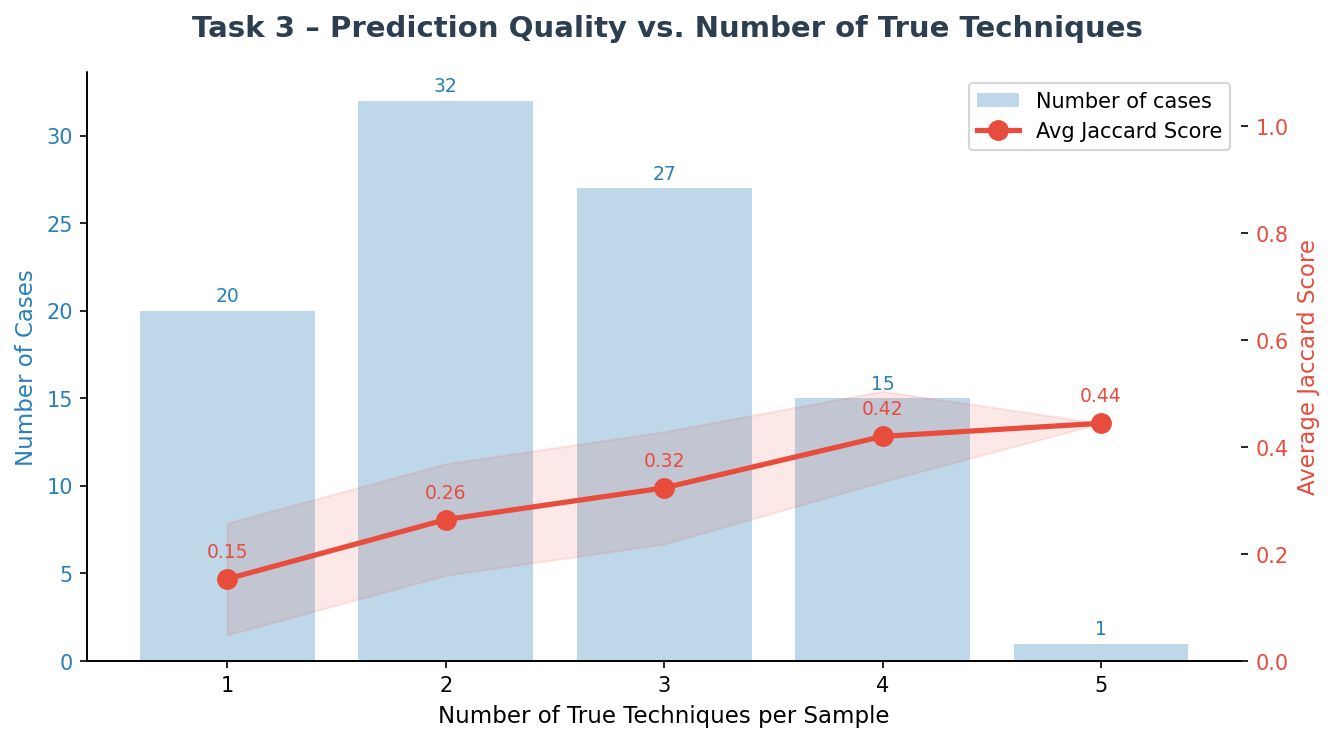

✅ Saved: task3_D_jaccard_by_complexity.png

[T3-D] Jaccard Score by Number of True Techniques (>= 1 only):
  Num Tech  Cases  Avg Jaccard     Std
  ------------------------------------
         1     20       0.1535  0.1045
         2     32       0.2644  0.1042
         3     27       0.3237  0.1050
         4     15       0.4200  0.0845
         5      1       0.4444  0.0000


In [17]:
# ── Figure T3-D: Jaccard by complexity (bắt đầu từ 1, bỏ 0) ──
rows_jac = []
for n in range(1, 6):   # ← bắt đầu từ 1, không còn n=0
    subset = test[test['num_true_techniques'] == n]
    if len(subset) == 0:
        continue
    jacs = []
    for _, row in subset.iterrows():
        t = set(row['true_techniques']); p = set(row['pred_techniques'])
        jacs.append(len(t & p) / len(t | p) if len(t | p) > 0 else 1.0)
    rows_jac.append({'n': n, 'count': len(subset),
                     'jaccard': np.mean(jacs), 'jaccard_std': np.std(jacs)})
df_jac = pd.DataFrame(rows_jac)

fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle("Task 3 – Prediction Quality vs. Number of True Techniques",
             fontsize=14, fontweight='bold', color=PALETTE['dark'])
ax2 = ax.twinx()
ax.bar(df_jac['n'], df_jac['count'], color=PALETTE['blue'], alpha=0.3,
       label='Number of cases')
ax2.plot(df_jac['n'], df_jac['jaccard'], 'o-', color=PALETTE['red'],
         linewidth=2.5, markersize=9, label='Avg Jaccard Score')
ax2.fill_between(df_jac['n'],
                 df_jac['jaccard']-df_jac['jaccard_std'],
                 df_jac['jaccard']+df_jac['jaccard_std'],
                 color=PALETTE['red'], alpha=0.12)
ax.set_xlabel("Number of True Techniques per Sample")
ax.set_ylabel("Number of Cases", color=PALETTE['blue'])
ax2.set_ylabel("Average Jaccard Score", color=PALETTE['red'])
ax.tick_params(axis='y', labelcolor=PALETTE['blue'])
ax2.tick_params(axis='y', labelcolor=PALETTE['red'])
ax2.set_ylim(0, 1.1)
ax.set_xticks(df_jac['n'])   # ← chỉ hiện tick từ 1 trở đi
for _, row in df_jac.iterrows():
    ax.text(row['n'], row['count']+0.5, str(int(row['count'])),
            ha='center', fontsize=9, color=PALETTE['blue'])
    ax2.text(row['n'], row['jaccard']+0.04, f"{row['jaccard']:.2f}",
             ha='center', fontsize=9, color=PALETTE['red'])
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, labels1+labels2, loc='upper right')
plt.tight_layout()
plt.savefig("task3_D_jaccard_by_complexity.png", bbox_inches='tight')
plt.show()
print("✅ Saved: task3_D_jaccard_by_complexity.png")

print("\n[T3-D] Jaccard Score by Number of True Techniques (>= 1 only):")
print(f"  {'Num Tech':>8}  {'Cases':>5}  {'Avg Jaccard':>11}  {'Std':>6}")
print("  " + "-"*36)
for _, row in df_jac.iterrows():
    print(f"  {int(row['n']):>8}  {int(row['count']):>5}  "
          f"{row['jaccard']:>11.4f}  {row['jaccard_std']:>6.4f}")


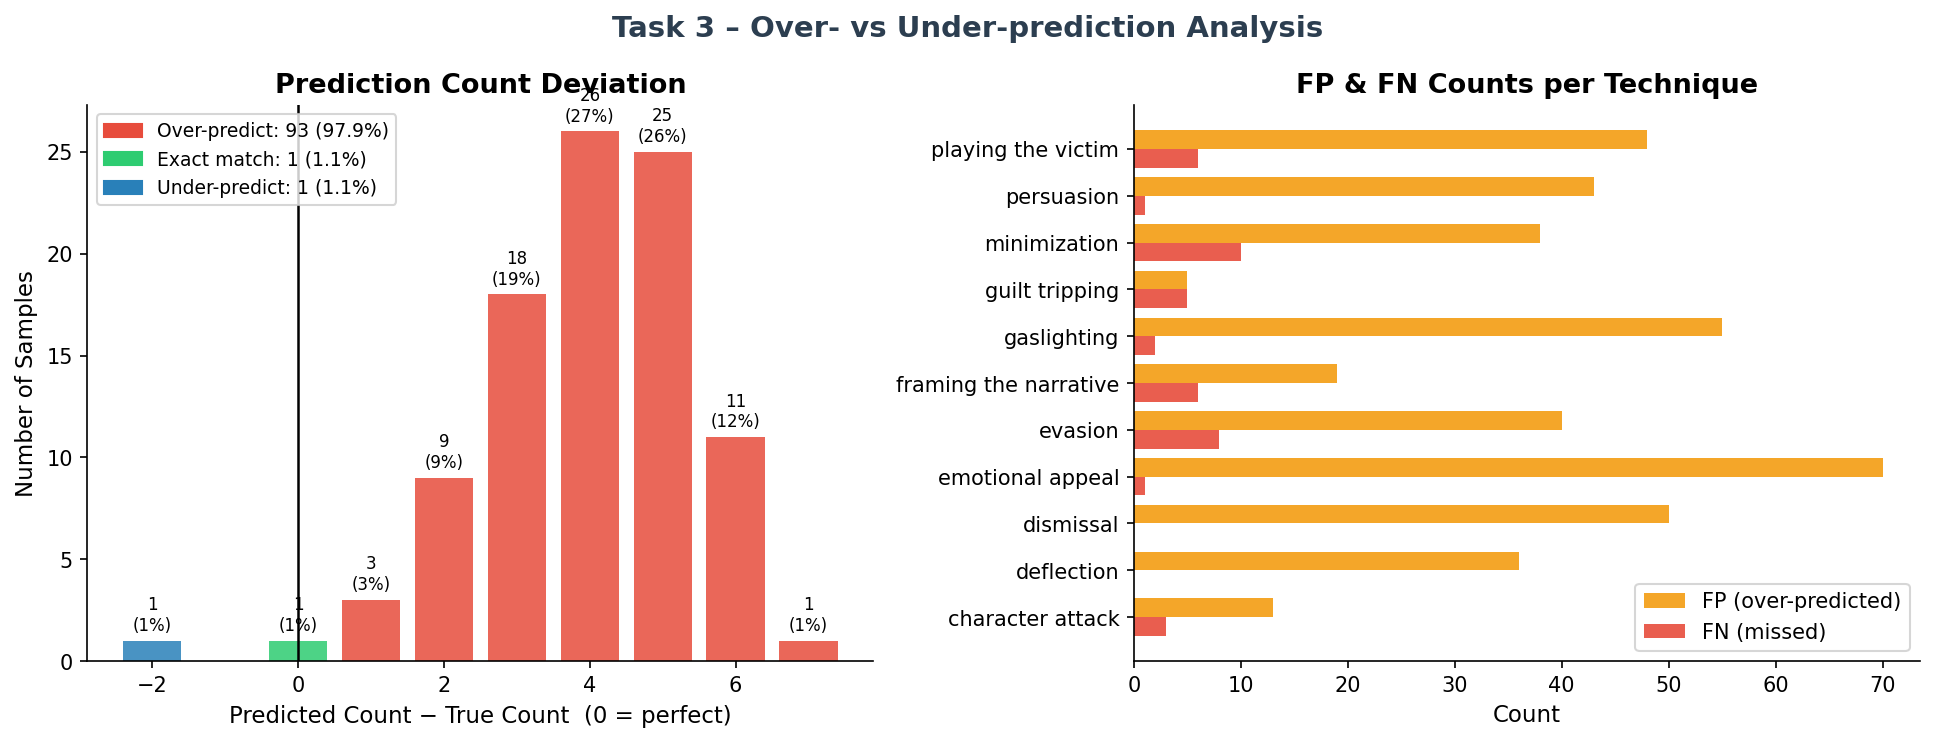

✅ Saved: task3_E_overprediction.png

[T3-E] Over/Under Prediction Summary (on 95 positive samples):
  Over-predict  :   93 (97.9%)
  Exact match   :    1 (1.1%)
  Under-predict :    1 (1.1%)

[T3-E] FP per Technique:
  Technique                    FP    FN
  -----------------------------------
  gaslighting                  55     2
  guilt tripping                5     5
  emotional appeal             70     1
  character attack             13     3
  deflection                   36     0
  framing the narrative        19     6
  minimization                 38    10
  evasion                      40     8
  dismissal                    50     0
  playing the victim           48     6
  persuasion                   43     1

✅ All figures and metrics printed.


In [18]:
# ── Figure T3-E: Over/Under prediction (trên test_pos) ────────
test_pos = test[test['Manipulative_bin'] == 1].copy()
diff       = test_pos['num_pred_techniques'] - test_pos['num_true_techniques']
diff_counts = diff.value_counts().sort_index()
over  = (diff > 0).sum()
under = (diff < 0).sum()
exact = (diff == 0).sum()

all_fp_list = [tech for _, row in test_pos.iterrows()
               for tech in set(row['pred_techniques']) - set(row['true_techniques'])]
all_fn_list = [tech for _, row in test_pos.iterrows()
               for tech in set(row['true_techniques']) - set(row['pred_techniques'])]
fp_cnt = Counter(all_fp_list)
fn_cnt = Counter(all_fn_list)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Task 3 – Over- vs Under-prediction Analysis",
             fontsize=14, fontweight='bold', color=PALETTE['dark'])

ax = axes[0]
bar_colors2 = [PALETTE['red'] if d > 0 else PALETTE['green'] if d == 0
               else PALETTE['blue'] for d in diff_counts.index]
ax.bar(diff_counts.index, diff_counts.values, color=bar_colors2, alpha=0.85)
ax.set_xlabel("Predicted Count − True Count  (0 = perfect)")
ax.set_ylabel("Number of Samples")
ax.set_title("Prediction Count Deviation")
total_pos = len(test_pos)
for xi, yi in zip(diff_counts.index, diff_counts.values):
    ax.text(xi, yi+0.5, f"{yi}\n({yi/total_pos*100:.0f}%)", ha='center', fontsize=8)
ax.axvline(0, color='black', linewidth=1.2)
legend_patches = [
    mpatches.Patch(color=PALETTE['red'],
                   label=f'Over-predict: {over} ({over/total_pos*100:.1f}%)'),
    mpatches.Patch(color=PALETTE['green'],
                   label=f'Exact match: {exact} ({exact/total_pos*100:.1f}%)'),
    mpatches.Patch(color=PALETTE['blue'],
                   label=f'Under-predict: {under} ({under/total_pos*100:.1f}%)'),
]
ax.legend(handles=legend_patches, fontsize=9)

ax = axes[1]
all_techs_plot = sorted(set(list(fp_cnt.keys()) + list(fn_cnt.keys())))
fp_vals = [fp_cnt.get(t, 0) for t in all_techs_plot]
fn_vals = [fn_cnt.get(t, 0) for t in all_techs_plot]
y = np.arange(len(all_techs_plot))
ax.barh(y+0.2, fp_vals, 0.4, color=PALETTE['orange'], alpha=0.9,
        label='FP (over-predicted)')
ax.barh(y-0.2, fn_vals, 0.4, color=PALETTE['red'],    alpha=0.9,
        label='FN (missed)')
ax.set_yticks(y); ax.set_yticklabels(all_techs_plot)
ax.set_xlabel("Count"); ax.set_title("FP & FN Counts per Technique")
ax.legend()
plt.tight_layout()
plt.savefig("task3_E_overprediction.png", bbox_inches='tight')
plt.show()
print("✅ Saved: task3_E_overprediction.png")

print(f"\n[T3-E] Over/Under Prediction Summary (on {total_pos} positive samples):")
print(f"  Over-predict  : {over:>4} ({over/total_pos*100:.1f}%)")
print(f"  Exact match   : {exact:>4} ({exact/total_pos*100:.1f}%)")
print(f"  Under-predict : {under:>4} ({under/total_pos*100:.1f}%)")

print(f"\n[T3-E] FP per Technique:")
print(f"  {'Technique':<25}  {'FP':>4}  {'FN':>4}")
print("  " + "-"*35)
for tech in ALL_TECHNIQUES:
    print(f"  {tech:<25}  {fp_cnt.get(tech,0):>4}  {fn_cnt.get(tech,0):>4}")

print("\n✅ All figures and metrics printed.")